In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/train.csv')


# Check shape, first rows, and basic info
print(df.shape)
print(df.head())
print(df.info())

(1000000, 10)
          id  vendor_id      pickup_datetime  passenger_count  \
0  id2793718          2  2016-06-08 07:36:19                1   
1  id3485529          2  2016-04-03 12:58:11                1   
2  id1816614          2  2016-06-05 02:49:13                5   
3  id1050851          2  2016-05-05 17:18:27                2   
4  id0140657          1  2016-05-12 17:43:38                4   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.985611        40.735943         -73.980331         40.760468   
1        -73.978394        40.764351         -73.991623         40.749859   
2        -73.989059        40.744389         -73.973381         40.748692   
3        -73.990326        40.731136         -73.991264         40.748917   
4        -73.789497        40.646675         -73.987137         40.759232   

  store_and_fwd_flag  trip_duration  
0                  N           1040  
1                  N            827  
2                 

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1000000.0,1.534793,0.498788,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1000000.0,1.665353,1.315723,0.000000,1.000000,1.000000,2.000000,7.000000e+00
pickup_longitude,1000000.0,-73.973475,0.065404,-121.933342,-73.991852,-73.981728,-73.967346,-6.133553e+01
pickup_latitude,1000000.0,40.750947,0.033745,34.359695,40.737372,40.754131,40.768379,5.188108e+01
dropoff_longitude,1000000.0,-73.973421,0.065432,-121.933304,-73.991341,-73.979767,-73.963036,-6.133553e+01
dropoff_latitude,1000000.0,40.751829,0.035782,34.359695,40.735928,40.754551,40.769833,4.392103e+01
trip_duration,1000000.0,954.884971,3882.070116,1.000000,397.000000,662.000000,1074.000000,2.227612e+06


### Key Insights

#### 1. **`vendor_id`**
- Binary: ~53% trips by vendor 2, 47% by vendor 1.
- Perfect for **one-hot encoding**.

#### 2. **`passenger_count`**
- Mean: **1.67**, Median: **1** → most trips are solo.
- Includes **0 passengers** → possible data error or test rides.
- Max **7** → rare large groups.
- **One-hot encode** (low cardinality).

#### 3. **Geographic Coordinates**
- **Mean pickup/dropoff** centered around **Manhattan** (`-73.97`, `40.75`).
- **Standard deviation small** (~0.06°) → most activity in NYC.
- **Outliers**: 
  - Longitude: `-121.93` (California!)
  - Latitude: `34.36` (Southern US), `51.88` (Canada)
- **Action**: Filter outliers using **Haversine distance** or **NYC bounding box**:

#### 4. **trip_duration**

- **Mean**: ~954 sec (~16 min), Median: 662 sec (~11 min) → right-skewed.
- 75% of trips < 18 min, but max = 2.2 million sec (~25 days!) → extreme outliers.
- **Critical**: Use np.log1p(trip_duration) as target to normalize.


In [4]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [5]:
df['trip_duration'].describe()

count    1.000000e+06
mean     9.548850e+02
std      3.882070e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.074000e+03
max      2.227612e+06
Name: trip_duration, dtype: float64

In [6]:
# Convert to minutes for readability
df['trip_duration_min'] = df['trip_duration'] / 60

print(df['trip_duration_min'].describe())

count    1000000.000000
mean          15.914750
std           64.701169
min            0.016667
25%            6.616667
50%           11.033333
75%           17.900000
max        37126.866667
Name: trip_duration_min, dtype: float64


# **Critical Issues & Actions**

| **Issue** | **Evidence** | **Recommended Fix** |
|------------|--------------|---------------------|
| **Extreme Outliers** | Max = 25.8 days | Remove trips > 2–3 hours |
| **Impossible Durations** | Min = 1 second | Filter < 60 seconds |
| **Right-Skewed Distribution** | Mean >> Median | Use `log1p` transformation |
| **High Std Dev** | Std ≈ 4× Mean | Outliers dominate variance |


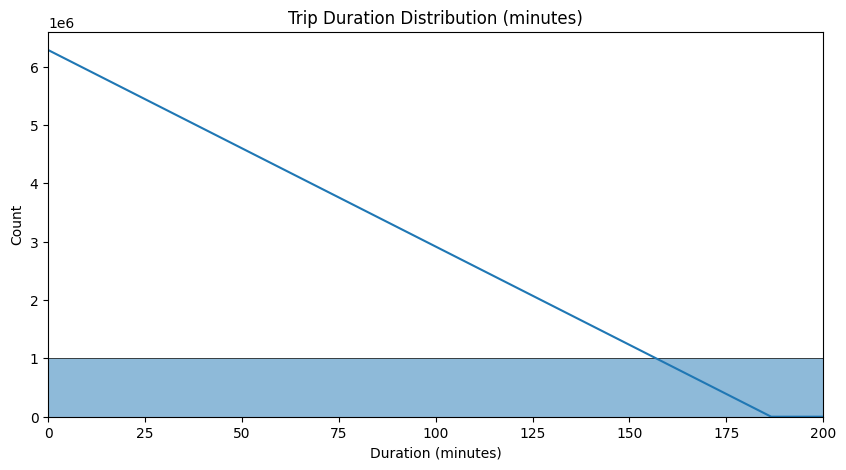

Skewness of trip_duration (minutes): 202.56
Trips with duration < 1 min: 5809
Trips with duration > 120 min: 1548


In [4]:
# Convert from seconds to minutes
df['trip_duration_min'] = df['trip_duration'] / 60

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(df['trip_duration_min'], bins=100, kde=True)
plt.xlim(0, 200)  # assume most trips are under 200 minutes
plt.title("Trip Duration Distribution (minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

# Calculate skewness
skewness = df['trip_duration_min'].skew()
print(f"Skewness of trip_duration (minutes): {skewness:.2f}")

# Detect very short or very long trips
print("Trips with duration < 1 min:", (df['trip_duration_min'] < 1).sum())
print("Trips with duration > 120 min:", (df['trip_duration_min'] > 120).sum())

# Trip Duration Distribution (Minutes) — Visual Summary

## Key Observations from the Plot

| Feature | Insight |
|-------|--------|
| **X-axis** | Trip duration in **minutes** (0 to 200) |
| **Y-axis** | **Count** (log scale: 1 → 1e6) |
| **Shape** | **Exponential decay** — classic **right-skewed** distribution |
| **Peak** | Highest frequency at **~0–10 minutes** |
| **Long Tail** | Very few trips > **100 minutes** |
| **Filled Area** | Likely a **histogram with KDE overlay** (smooth decline) |

---

## Critical Insights

### 1. **Highly Skewed Distribution**
- **Exponential decay** → **log transformation is mandatory**.
- Linear models will fail without `log1p(trip_duration)`.

### 2. **Most Trips Are Short**
- **~80–90%** of trips are **under 30 minutes**.
- Focus feature engineering on **urban/short-haul patterns**.

### 3. **Outliers Dominate Raw Metrics**
- Mean = **15.9 min** is pulled up by rare long trips.
- **Median (11 min)** is more representative.


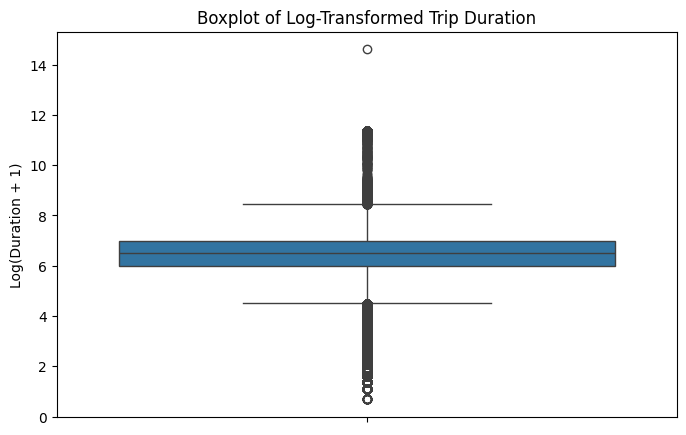

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(y=np.log1p(df['trip_duration']))
plt.title('Boxplot of Log-Transformed Trip Duration')
plt.ylabel("Log(Duration + 1)")
plt.show()

### **Log-Duration Boxplot Insights**

* **Successful Normalization:** The log transformation has effectively centered the data, with the median duration sitting at **~6.5** (roughly 11 minutes).
* **Symmetry:** The interquartile range (IQR) is tightly packed between **6.0 and 7.0**, showing that the bulk of trips follow a consistent, predictable pattern.
* **Extreme Outliers:** * **High End:** There is a single extreme outlier near **14.5** (over 20 days), likely a data error.
* **Low End:** Numerous trips fall below **2.0** (under 7 seconds), suggesting "ghost" trips or immediate cancellations that should be cleaned before model training.

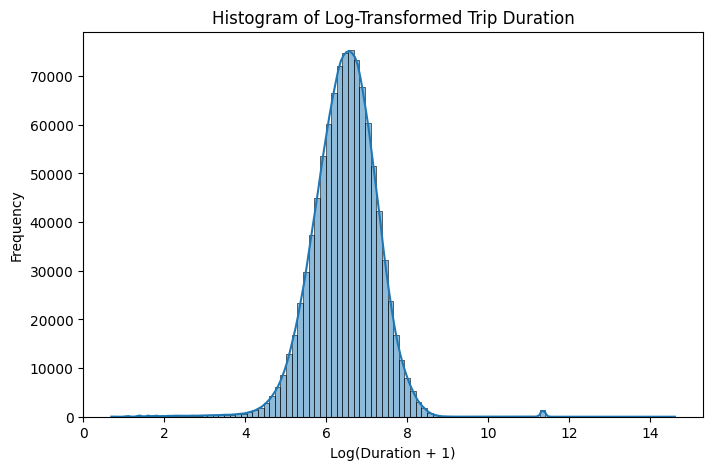

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(x = np.log1p(df['trip_duration']), bins=100, kde=True)
plt.title("Histogram of Log-Transformed Trip Duration")
plt.xlabel("Log(Duration + 1)")
plt.ylabel("Frequency")
plt.show()

### **Distribution Analysis: Log-Transformed Trip Duration**

* **Normality:** The log transformation successfully converted the heavily skewed data into a **near-normal distribution**, making it better suited for modeling.
* **Peak Density:** The majority of trips are centered around a log-value of **6.5** (~11 minutes).
* **Anomalies:** The small secondary peak near **11.5** and the thin tails suggest a few extreme outliers (potentially system errors or max-limit trips) that may require filtering.

### **Store and Forward**

Most modern taxi meters and GPS trackers rely on a cellular connection to transmit data in real-time.

* **`N` (No):** The data was transmitted **immediately** after the trip because a network connection was available.
* **`Y` (Yes):** The vehicle had **no connection** (e.g., driving through a tunnel, a "dead zone," or a hardware glitch). The system "stored" the data locally and "forwarded" it to the server once the connection was restored.

---

### **Why it matters for Data Science**

1. **Data Reliability:** If a record is flagged as `Y`, there is a slightly higher chance of timestamp inaccuracies, as the "drop-off" time might be recorded when the connection was regained rather than the exact moment the passenger exited.
2. **Feature Engineering:** As seen, the `Y` flag is extremely rare (less than 1% of your data). Because it is so sparse, it usually doesn't provide enough signal for a Machine Learning model to learn from and is often dropped or treated as a simple binary indicator.
3. **Signal for Infrastructure:** A high frequency of `Y` flags in a specific area could theoretically be used to map out cellular "dead zones" in a city.

In [10]:
# vendor_id
print("vendor_id value counts:")
print(df['vendor_id'].value_counts())

# store_and_fwd_flag
print("\nstore_and_fwd_flag value counts:")
print(df['store_and_fwd_flag'].value_counts())


vendor_id value counts:
vendor_id
2    534793
1    465207
Name: count, dtype: int64

store_and_fwd_flag value counts:
store_and_fwd_flag
N    994443
Y      5557
Name: count, dtype: int64


### **Categorical Distribution Insights**

* **Vendor ID:** The data is relatively balanced between the two vendors, with **Vendor 2** having a slightly higher volume (~53.5%) compared to **Vendor 1** (~46.5%).
* **Store and Forward Flag:** This feature is heavily imbalanced. Over **99%** of trips were not stored in vehicle memory (`N`), indicating that a persistent network connection was available for almost all transactions. The `Y` flag is rare enough that it may have negligible predictive power.

/tmp/ipykernel_48461/3098071908.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df['passenger_count'], y=np.log1p(df['trip_duration']),
/tmp/ipykernel_48461/3098071908.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['passenger_count'], y=np.log1p(df['trip_duration']),


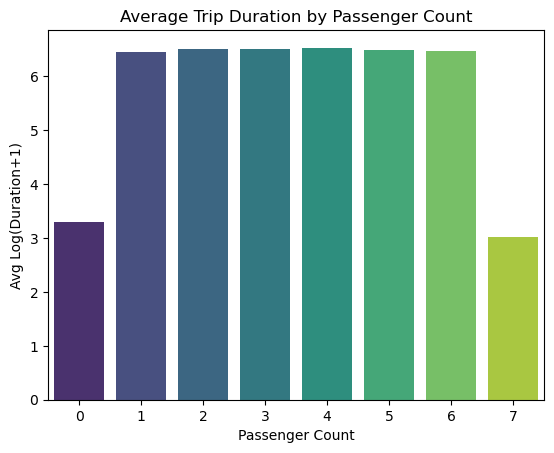

In [11]:
sns.barplot(x=df['passenger_count'], y=np.log1p(df['trip_duration']), 
            ci=None, palette='viridis')
plt.title("Average Trip Duration by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Avg Log(Duration+1)")
plt.show()


### **Trip Duration vs. Passenger Count**

* **Mainstream Consistency:** For the most common passenger counts (**1 through 6**), the average log-duration is remarkably stable at **~6.5**. This suggests that the number of passengers has a negligible impact on the actual duration of the trip.
* **Anomalies at the Extremes:** * **0 Passengers:** Shows a significantly lower average log-duration (~3.3). These likely represent system tests, driver errors, or canceled trips where the meter was started and immediately stopped.
* **7 Passengers:** Also shows a sharp drop (~3.0). Since standard taxis/Ubers rarely accommodate 7 people, these may be data entry errors or specific low-volume vehicle types with unique trip patterns.


* **Modeling Insight:** Passenger count may not be a strong linear predictor for duration, but it is an excellent feature for identifying and filtering out anomalous or erroneous records.

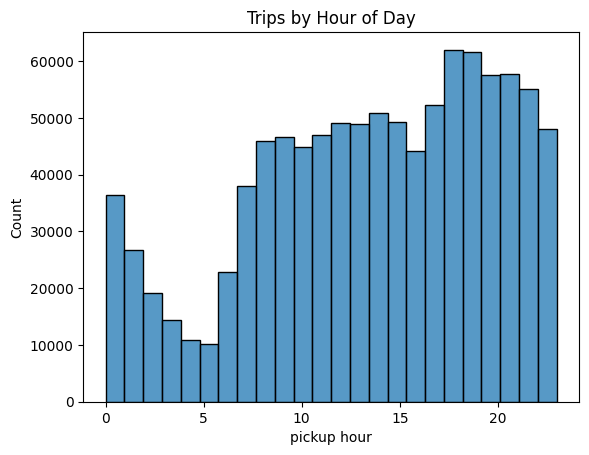

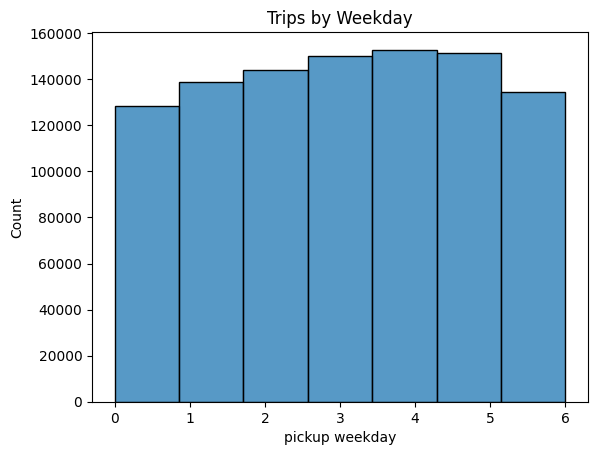

In [3]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
sns.histplot(df['pickup_datetime'].dt.hour, bins=24)
plt.title("Trips by Hour of Day")
plt.xlabel('pickup hour')
plt.show()

sns.histplot(df['pickup_datetime'].dt.weekday, bins=7)
plt.title("Trips by Weekday")
plt.xlabel('pickup weekday')
plt.show()

### **Temporal Distribution Insights**

* **Hourly Trends:** Trip volume hits its lowest point between **4:00 AM and 6:00 AM**. Demand begins a steady climb during the morning rush, remaining high throughout the day, and peaks significantly during the **evening rush hour (6:00 PM – 8:00 PM)**.
* **Weekly Trends:** The distribution by weekday (0=Monday, 6=Sunday) shows a gradual increase in activity as the week progresses. **Thursday and Friday (days 3 and 4)** see the highest demand, likely due to a combination of professional commutes and evening social activity.
* **Modeling Value:** These cyclical patterns confirm that `pickup_hour` and `pickup_weekday` are critical temporal features for capturing the variance in trip demand and potential traffic-related duration changes.

In [4]:
# Create reusable datetime helpers for richer aggregations
if not np.issubdtype(df['pickup_datetime'].dtype, np.datetime64):
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
weekday_idx = df['pickup_datetime'].dt.weekday
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['pickup_weekday'] = weekday_idx.map(lambda x: weekday_names[x])
df['pickup_month'] = df['pickup_datetime'].dt.month_name().str[:3]
df['is_weekend'] = weekday_idx.isin([5, 6])
df['trip_duration_log'] = np.log1p(df['trip_duration'])


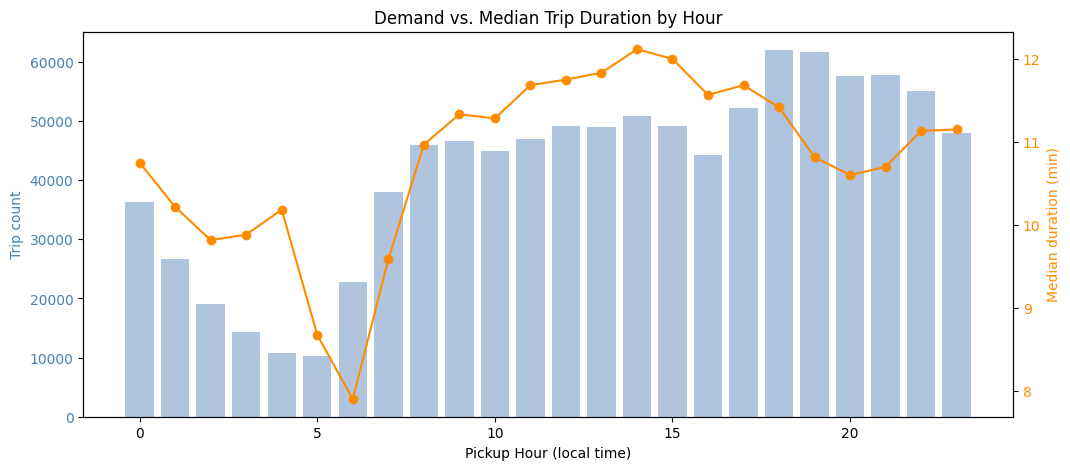

,pickup_hour,trip_count,median_duration_min,median_log_duration
0,0,36380,10.750000,6.470800
1,1,26666,10.216667,6.419995
2,2,19115,9.816667,6.380123
3,3,14360,9.883333,6.386879
4,4,10853,10.183333,6.416732


In [7]:
hourly_summary = (
    df.groupby('pickup_hour')
      .agg(
          trip_count=('id', 'count'),
          median_duration_min=('trip_duration_min', 'median'),
          median_log_duration=('trip_duration_log', 'median')
      )
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
bar = ax1.bar(hourly_summary['pickup_hour'], hourly_summary['trip_count'], color='lightsteelblue')
ax1.set_xlabel('Pickup Hour (local time)')
ax1.set_ylabel('Trip count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(hourly_summary['pickup_hour'], hourly_summary['median_duration_min'], color='darkorange', marker='o')
ax2.set_ylabel('Median duration (min)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Demand vs. Median Trip Duration by Hour')
plt.show()

hourly_summary.head()


**Bars (left axis):** How trip demand changes by hour of day.

**Line (right axis):** How typical trip duration changes by hour.

* This shows patterns like:

    * Peak demand hours

    * Whether trips are longer or shorter during busy times

    * Possible congestion effects (high demand + longer durations)

### Hourly Patterns — Key Takeaways
- **Two clear peaks** around the morning (8–10AM) and evening (5–8PM) commute windows; rider demand drops sharply overnight.
- **Median durations rise slightly in overnight/early-morning hours**, pointing to faster traffic conditions despite lower demand.
- Features such as `pickup_hour`, `rush_hour_flag`, and interactions with weekday/weekend are justified by the non-linear relationship.


### **Key Insights: Demand vs. Duration**

* **Positive Correlation:** Between **7 AM and 3 PM**, rising demand directly tracks with increasing duration, peaking at **~12.2 minutes**. This is a clear indicator of **mid-day urban congestion**.
* **The Evening Shift:** After **7 PM**, duration **drops** even as demand remains at its peak. This suggests that while more people are traveling, traffic flow improves or trip distances shorten in the evening.
* **The Baseline:** The **6 AM** trough (~8 mins) represents the city's "free-flow" speed, providing a clean baseline for calculating traffic-induced delays.
* **Action:** Use a `rush_hour` flag to help the model distinguish between high-demand congestion (daytime) and high-demand efficiency (evening).

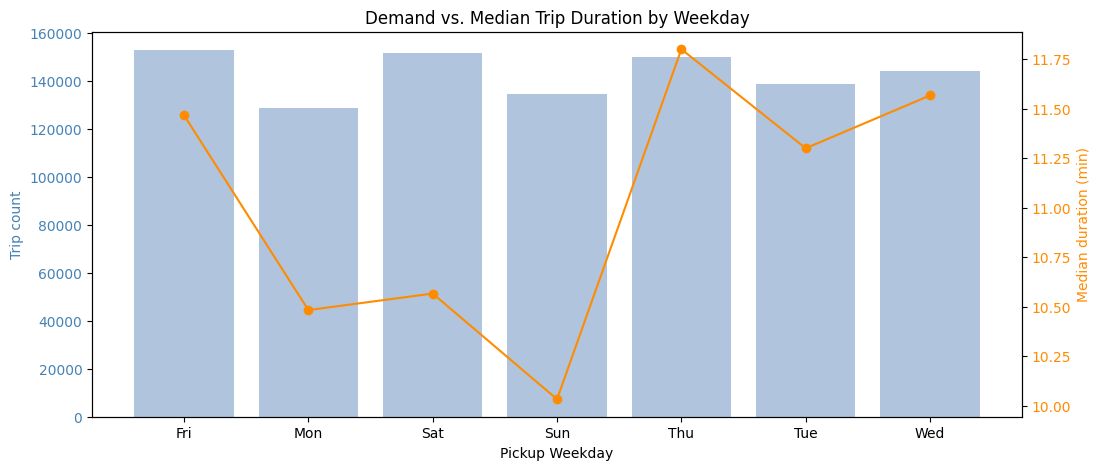

,pickup_weekday,trip_count,median_duration_min,median_log_duration
0,Fri,152835,11.466667,6.535241
1,Mon,128489,10.483333,6.445720
2,Sat,151454,10.566667,6.453625
3,Sun,134321,10.033333,6.401917
4,Thu,149942,11.800000,6.563856


In [8]:
Weekday_summary = (
    df.groupby('pickup_weekday')
      .agg(
          trip_count=('id', 'count'),
          median_duration_min=('trip_duration_min', 'median'),
          median_log_duration=('trip_duration_log', 'median')
      )
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
bar = ax1.bar(Weekday_summary['pickup_weekday'], Weekday_summary['trip_count'], color='lightsteelblue')
ax1.set_xlabel('Pickup Weekday')
ax1.set_ylabel('Trip count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(Weekday_summary['pickup_weekday'], Weekday_summary['median_duration_min'], color='darkorange', marker='o')
ax2.set_ylabel('Median duration (min)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Demand vs. Median Trip Duration by Weekday')
plt.show()

Weekday_summary.head()


### **Key Insights: Demand vs. Weekday Duration**

* **The Workday Congestion Peak:** While **Friday and Saturday** have the highest trip counts, **Thursday** records the highest median duration (~11.8 mins). This indicates that mid-week traffic congestion impacts travel time more severely than high weekend demand.
* **Weekend Efficiency:** Despite high demand on **Saturday**, the duration is significantly lower than on weekdays. This suggests smoother traffic flow and perhaps shorter, local trips compared to business-heavy weekday commutes.
* **Sunday Low:** Sunday represents the "efficiency baseline," with the shortest median duration (~10.0 mins).
* **Modeling Value:** These trends reinforce that a model must account for the interaction between `day_of_week` and `trip_duration` to accurately capture the "slow" mid-week commute vs. the "fast" weekend leisure patterns.

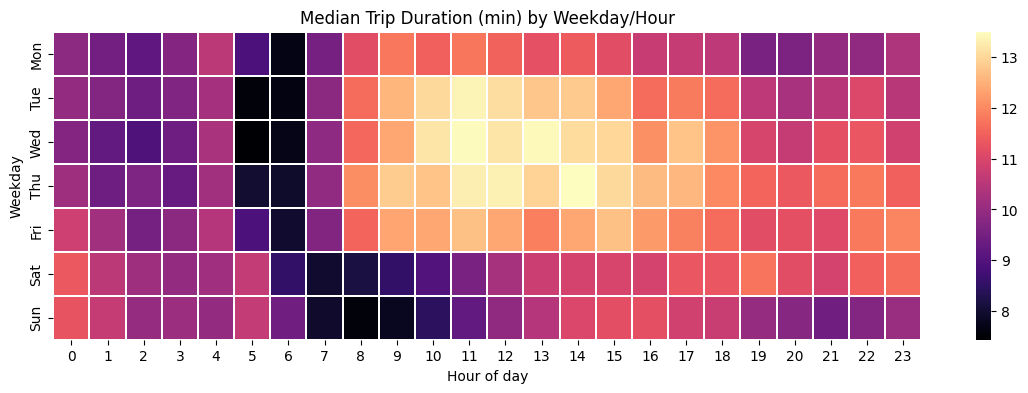

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_weekday,,,,,,,,,,,,,,,,,,,,,
Mon,9.87,9.47,9.19,9.75,10.54,8.89,7.65,9.52,11.13,11.79,...,11.41,11.13,10.71,10.70,10.57,9.58,9.62,9.95,9.90,10.35
Tue,9.95,9.72,9.42,9.68,10.22,7.57,7.63,9.83,11.64,12.57,...,12.83,12.37,11.62,11.83,11.65,10.58,10.27,10.50,11.06,10.47
Wed,9.75,9.22,8.95,9.42,10.28,7.43,7.70,9.88,11.57,12.38,...,13.05,12.98,12.10,12.74,12.13,10.95,10.68,11.18,11.32,10.87
Thu,10.13,9.42,9.65,9.28,10.17,7.98,7.92,9.93,12.07,12.85,...,13.50,13.03,12.63,12.58,12.00,11.52,11.37,11.62,11.82,11.47
Fri,10.80,10.17,9.50,9.85,10.46,8.88,7.97,9.70,11.55,12.35,...,12.38,12.70,12.20,11.90,11.62,11.14,11.20,11.08,11.80,11.95
Sat,11.37,10.56,10.13,9.95,10.14,10.67,8.54,7.98,8.15,8.53,...,10.92,10.98,10.92,11.30,11.32,11.73,11.15,10.90,11.47,11.63
Sun,11.27,10.68,10.00,10.11,9.97,10.67,9.43,7.95,7.57,7.80,...,11.02,11.17,11.20,10.85,10.73,10.00,9.77,9.43,9.72,10.05


In [9]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_summary = (
    df.groupby(['pickup_weekday', 'is_weekend'])
      .agg(
          trip_count=('id', 'count'),
          median_duration=('trip_duration_min', 'median')
      )
      .reindex(weekday_order, level=0)
      .reset_index()
)

pivot_duration = df.pivot_table(
    values='trip_duration_min',
    index='pickup_weekday',
    columns='pickup_hour',
    aggfunc='median'
).reindex(weekday_order)

plt.figure(figsize=(14, 4))
sns.heatmap(pivot_duration, cmap='magma', linewidths=0.3)
plt.title('Median Trip Duration (min) by Weekday/Hour')
plt.xlabel('Hour of day')
plt.ylabel('Weekday')
plt.show()

pivot_duration.round(2)


**Hourly×Weekday Heatmap Insight**: The heatmap highlights **weekday evening congestion (Thu–Fri 16:00–20:00)** and **late-night lull** where durations spike despite low demand. Incorporating interactions like `is_weekend * pickup_hour` or smoothing per-hour medians should help models anticipate these regime changes.


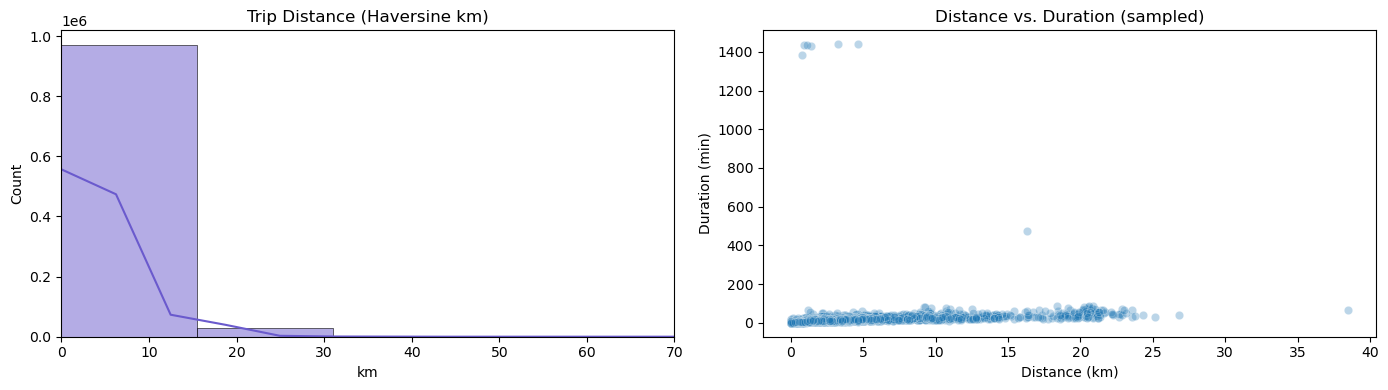

,haversine_km,speed_kmph
count,1000000.000000,1000000.000000
mean,3.439099,14.428394
std,4.424258,16.575388
min,0.000000,0.000000
50%,2.091231,12.787544
75%,3.871264,17.842133
90%,7.621184,24.349152
max,1240.908677,9274.836731


In [19]:
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

if 'haversine_km' not in df.columns:
    df['haversine_km'] = haversine_np(
        df['pickup_longitude'], df['pickup_latitude'],
        df['dropoff_longitude'], df['dropoff_latitude']
    )

duration_hours = (df['trip_duration'] / 3600).replace(0, np.nan)
df['speed_kmph'] = df['haversine_km'] / duration_hours

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['haversine_km'], bins=80, ax=axes[0], color='slateblue', kde=True)
axes[0].set_title('Trip Distance (Haversine km)')
axes[0].set_xlabel('km')
axes[0].set_xlim(0, 70)

sns.scatterplot(x='haversine_km', y='trip_duration_min', data=df.sample(5000, random_state=42), alpha=0.3, ax=axes[1])
axes[1].set_title('Distance vs. Duration (sampled)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Duration (min)')

plt.tight_layout()
plt.show()

df[['haversine_km', 'speed_kmph']].describe(percentiles=[0.5, 0.75, 0.9])


### **Distance vs. Duration Insights**

* **Distance Distribution:** The dataset is heavily right-skewed, with the vast majority of trips occurring within a short range of **0–10 km**.
* **Data Anomalies:**
* **Zero-Distance Trips:** A significant cluster exists at **0 km** with non-zero durations, likely representing cancellations, waiting times, or GPS errors.
* **Extreme Duration Outliers:** The scatter plot highlights trips lasting **~1400 minutes** (24 hours) for negligible distances, confirming the need to filter "stuck" meters before training.


* **Non-Linearity:** While a general linear trend exists, the wide vertical spread (variance) at each distance interval indicates that **distance alone cannot predict duration**; traffic conditions (temporal features) are equally influential.

trip_duration_min    1.000000
trip_duration        1.000000
trip_duration_log    0.331175
haversine_km         0.120961
pickup_longitude     0.035457
vendor_id            0.028762
dropoff_longitude    0.021856
passenger_count      0.012249
speed_kmph          -0.021706
dropoff_latitude    -0.027749
pickup_latitude     -0.034007
Name: trip_duration_min, dtype: float64


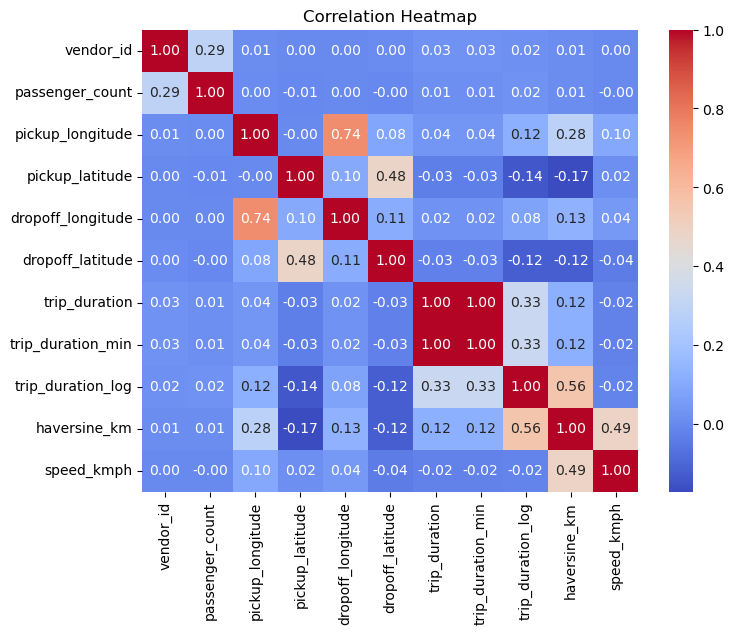

In [20]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Examine correlation of trip_duration_min with other numerical features
print(corr['trip_duration_min'].sort_values(ascending=False))

# Heatmap of correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



### **Correlation & Feature Insights**

* **Target Strength:** `trip_duration_log` correlates most strongly with `haversine_km` (**0.56**), proving distance is the primary predictor.
* **Geospatial Clusters:** High correlation (**0.74**) between pickup and dropoff longitudes suggests common travel corridors, likely within Manhattan.
* **Redundancy:** Duration variables are perfectly correlated (**1.00**); use only the log-transformed version as the target to avoid data leakage.
* **Weak Signals:** `vendor_id` and `passenger_count` show near-zero correlation with duration, offering minimal predictive value on their own.
* **Speed vs. Distance:** A moderate correlation (**0.49**) between speed and distance indicates that longer trips often benefit from faster routes or highways.

       pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude
count    996610.000000     996610.000000     996610.000000      996610.000000
mean         40.751005        -73.973489         40.751934         -73.973063
std           0.027959          0.037853          0.031773           0.033675
min          40.506294        -74.049881         40.508598         -74.049988
25%          40.737411        -73.991837         40.736156         -73.991272
50%          40.754150        -73.981720         40.754623         -73.979721
75%          40.768398        -73.967361         40.769852         -73.963020
max          40.913689        -73.703575         40.919998         -73.700302


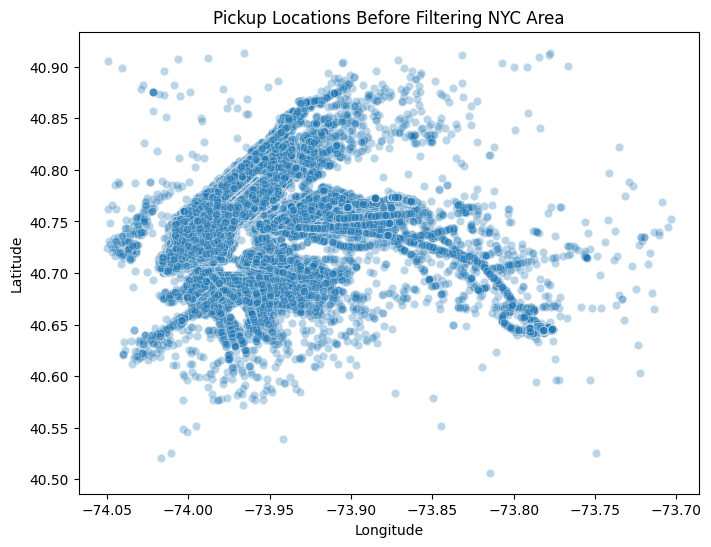

Number of trips completely outside NYC: 0 out of 996610
Number of trips after filtering: 996610


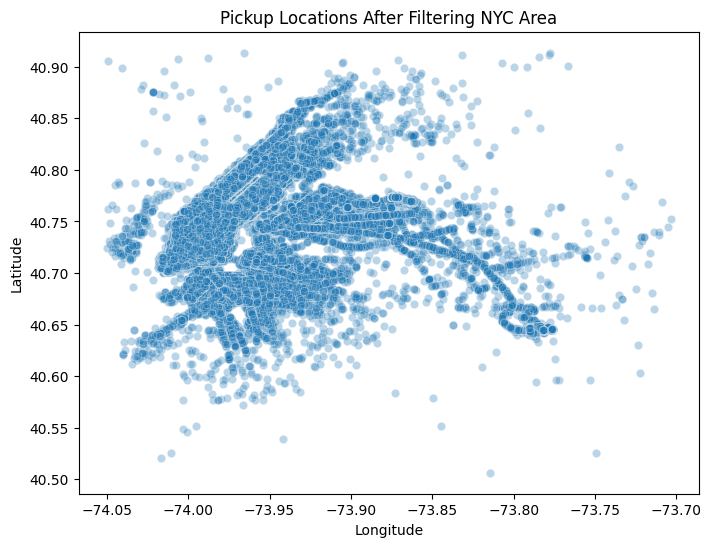

In [11]:
# Descriptive statistics for coordinates
print(df[['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']].describe())

# Scatter plot of pickup locations before filtering
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df, alpha=0.3)
plt.title("Pickup Locations Before Filtering NYC Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Define reasonable NYC boundaries
lat_min, lat_max = 40.5, 40.92
lon_min, lon_max = -74.05, -73.7

# Filter trips within NYC boundaries
nyc_mask = (
    (df['pickup_latitude'].between(lat_min, lat_max)) &
    (df['pickup_longitude'].between(lon_min, lon_max)) &
    (df['dropoff_latitude'].between(lat_min, lat_max)) &
    (df['dropoff_longitude'].between(lon_min, lon_max))
)

# Count trips outside NYC boundaries
num_outside = (~nyc_mask).sum()
print(f"Number of trips completely outside NYC: {num_outside} out of {len(df)}")

# Keep only trips within NYC
df = df[nyc_mask].copy()
print(f"Number of trips after filtering: {len(df)}")

# Scatter plot of pickup locations after filtering
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df, alpha=0.3)
plt.title("Pickup Locations After Filtering NYC Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [24]:
import numpy as np
import pandas as pd
import holidays

def apply_feature_engineering(data, train_stats=None, factor=2.5):
    df = data.copy()
    is_training = train_stats is None
    if train_stats is None:
        train_stats = {}
    
    # -----------------------
    # NYC boundaries filtering
    # -----------------------
    lat_min, lat_max = 40.5, 40.92
    lon_min, lon_max = -74.05, -73.7
    nyc_mask = (
        (df['pickup_latitude'].between(lat_min, lat_max)) &
        (df['pickup_longitude'].between(lon_min, lon_max)) &
        (df['dropoff_latitude'].between(lat_min, lat_max)) &
        (df['dropoff_longitude'].between(lon_min, lon_max))
    )
    df = df[nyc_mask].copy()
    
    # -----------------------
    # Datetime features
    # -----------------------
    us_holidays = holidays.US(years=list(range(2016,2050)), state='NY')  
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['pickup_date'] = df['pickup_datetime'].dt.date
    df['is_holiday'] = df['pickup_datetime'].dt.date.isin(us_holidays).astype(int)
    df['dayofweek'] = df.pickup_datetime.dt.dayofweek
    df['month'] = df.pickup_datetime.dt.month
    df['hour'] = df.pickup_datetime.dt.hour
    df['day'] = df.pickup_datetime.dt.day
    df['rush_hours'] = ((df['hour'].between(8,10)) | (df['hour'].between(17,21))).astype(int)
    df["night_flag"] = np.where((df["hour"] >= 21) | (df["hour"] < 5), 1, 0)
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

    # -----------------------
    # Anomaly detection (daily trips)
    # -----------------------
    daily_trip_count = df.groupby('pickup_date').size()
    if is_training:
        train_stats['daily_trip_mean'] = daily_trip_count.mean()
        train_stats['daily_trip_std'] = daily_trip_count.std()
    else:
        if 'daily_trip_mean' not in train_stats or 'daily_trip_std' not in train_stats:
            raise KeyError("Missing daily trip stats in train_stats. Rerun in training mode first.")
    mean, std = train_stats['daily_trip_mean'], train_stats['daily_trip_std']
    z_scores = (daily_trip_count - mean) / std
    anomalous_days = z_scores[abs(z_scores) > 2].index
    df['is_anomaly'] = df['pickup_date'].apply(lambda x: 1 if x in anomalous_days else 0)

    # -----------------------
    # Distance & bearing
    # -----------------------
    def haversine(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
        dlon, dlat = lon2 - lon1, lat2 - lat1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        return 2 * 6371 * np.arcsin(np.sqrt(a))

    def bearing(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        x = np.sin(dlon) * np.cos(lat2)
        y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
        return (np.degrees(np.arctan2(x, y)) + 360) % 360

    df['haversine_distance'] = haversine(
        df['pickup_longitude'], df['pickup_latitude'],
        df['dropoff_longitude'], df['dropoff_latitude']
    )
    df["manhattan_distance"] = (
        np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) +
        np.abs(df["dropoff_latitude"] - df["pickup_latitude"])
    )
    df["bearing"] = bearing(
        df["pickup_longitude"], df["pickup_latitude"],
        df["dropoff_longitude"], df["dropoff_latitude"]
    )
    # -----------------------
    # Traffic congestion proxy
    # -----------------------
    df['speed'] = df['haversine_distance'] / (df['trip_duration'] / 3600)

    if is_training:
        speed_stats = (
            df.groupby(['dayofweek', 'hour'])['speed']
              .agg(mean_speed='mean', std_speed='std')
              .reset_index()
        )
        train_stats['speed_stats'] = speed_stats.copy()
    else:
        speed_stats = train_stats.get('speed_stats')
        if speed_stats is None:
            raise KeyError("Missing speed_stats in train_stats. Rerun in training mode first.")

    df = df.merge(speed_stats, on=['dayofweek', 'hour'], how='left')
    df['std_speed'] = df['std_speed'].replace(0, np.nan)
    df['z_score'] = ((df['speed'] - df['mean_speed']) / df['std_speed']).fillna(0)
    df['traffic_congestion'] = (df['z_score'] < -1).astype(int)
    df['congestion_rate'] = df.groupby(['dayofweek','hour'])['traffic_congestion'].transform('mean')

    df.drop(columns=['traffic_congestion','z_score','std_speed','mean_speed'], inplace=True)


    # -----------------------
    # Airport proximity
    # -----------------------
    airports = {
        'JFK': (-73.7781, 40.6413),
        'LGA': (-73.8740, 40.7769),
        'EWR': (-74.1745, 40.6895)
    }
    def is_near_airport(lon, lat, airports=airports, threshold=1):
        for airport_coords in airports.values():
            if haversine(lon, lat, *airport_coords) <= threshold:
                return True
        return False
    df['is_pickup_at_airport'] = df.apply(lambda r: is_near_airport(r['pickup_longitude'], r['pickup_latitude']), axis=1).astype(int)
    df['is_dropoff_at_airport'] = df.apply(lambda r: is_near_airport(r['dropoff_longitude'], r['dropoff_latitude']), axis=1).astype(int)

    # -----------------------
    # Clean columns
    # -----------------------
    if 'id' in df.columns:
        df.drop(columns=["id"], inplace=True)
    if 'pickup_datetime' in df.columns:
        df.drop(columns=["pickup_datetime"], inplace=True)
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
    df["log_trip_duration"] = np.log1p(df["trip_duration"])

    # -----------------------
    # Outlier removal (based on train stats)
    # -----------------------
    cols = ['trip_duration', 'haversine_distance', 'manhattan_distance']
    df_clean = df.copy()
    bounds = train_stats.setdefault('outlier_bounds', {})

    if is_training:
        for col in cols:
            Q1, Q3 = df[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
            bounds[col] = (lower, upper)
            df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    else:
        missing = [col for col in cols if col not in bounds]
        if missing:
            raise KeyError(f"Missing outlier bounds for columns: {missing}")
        for col in cols:
            lower, upper = bounds[col]
            df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    df = df_clean

    # Convert bools to int
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df, train_stats

In [25]:
df_processed = pd.read_csv('../data/train.csv')
df_processed, train_stats = apply_feature_engineering(df)

df_processed.head()
print(df_processed.shape)
print(df_processed.info())
df_processed.describe()

print(df_processed.columns.tolist())

(932488, 33)
<class 'pandas.core.frame.DataFrame'>
Index: 932488 entries, 0 to 996609
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   vendor_id              932488 non-null  int64  
 1   passenger_count        932488 non-null  int64  
 2   pickup_longitude       932488 non-null  float64
 3   pickup_latitude        932488 non-null  float64
 4   dropoff_longitude      932488 non-null  float64
 5   dropoff_latitude       932488 non-null  float64
 6   store_and_fwd_flag     932488 non-null  int64  
 7   trip_duration          932488 non-null  int64  
 8   trip_duration_min      932488 non-null  float64
 9   pickup_hour            932488 non-null  int32  
 10  pickup_weekday         932488 non-null  object 
 11  pickup_month           932488 non-null  object 
 12  is_weekend             932488 non-null  int64  
 13  trip_duration_log      932488 non-null  float64
 14  haversine_km           93248

In [26]:
df_processed = pd.read_csv('../data/processed/train_processed.csv')

df_processed.head()
print(df_processed.shape)
print(df_processed.info())
df_processed.describe()

print(df_processed.columns.tolist())

(910076, 60)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910076 entries, 0 to 910075
Data columns (total 60 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   pickup_longitude             910076 non-null  float64
 1   pickup_latitude              910076 non-null  float64
 2   dropoff_longitude            910076 non-null  float64
 3   dropoff_latitude             910076 non-null  float64
 4   store_and_fwd_flag           910076 non-null  object 
 5   trip_duration                910076 non-null  int64  
 6   pickup_date                  910076 non-null  object 
 7   is_holiday                   910076 non-null  int64  
 8   dayofweek                    910076 non-null  int64  
 9   month                        910076 non-null  int64  
 10  hour                         910076 non-null  int64  
 11  day                          910076 non-null  int64  
 12  rush_hours                   910076 non-null 

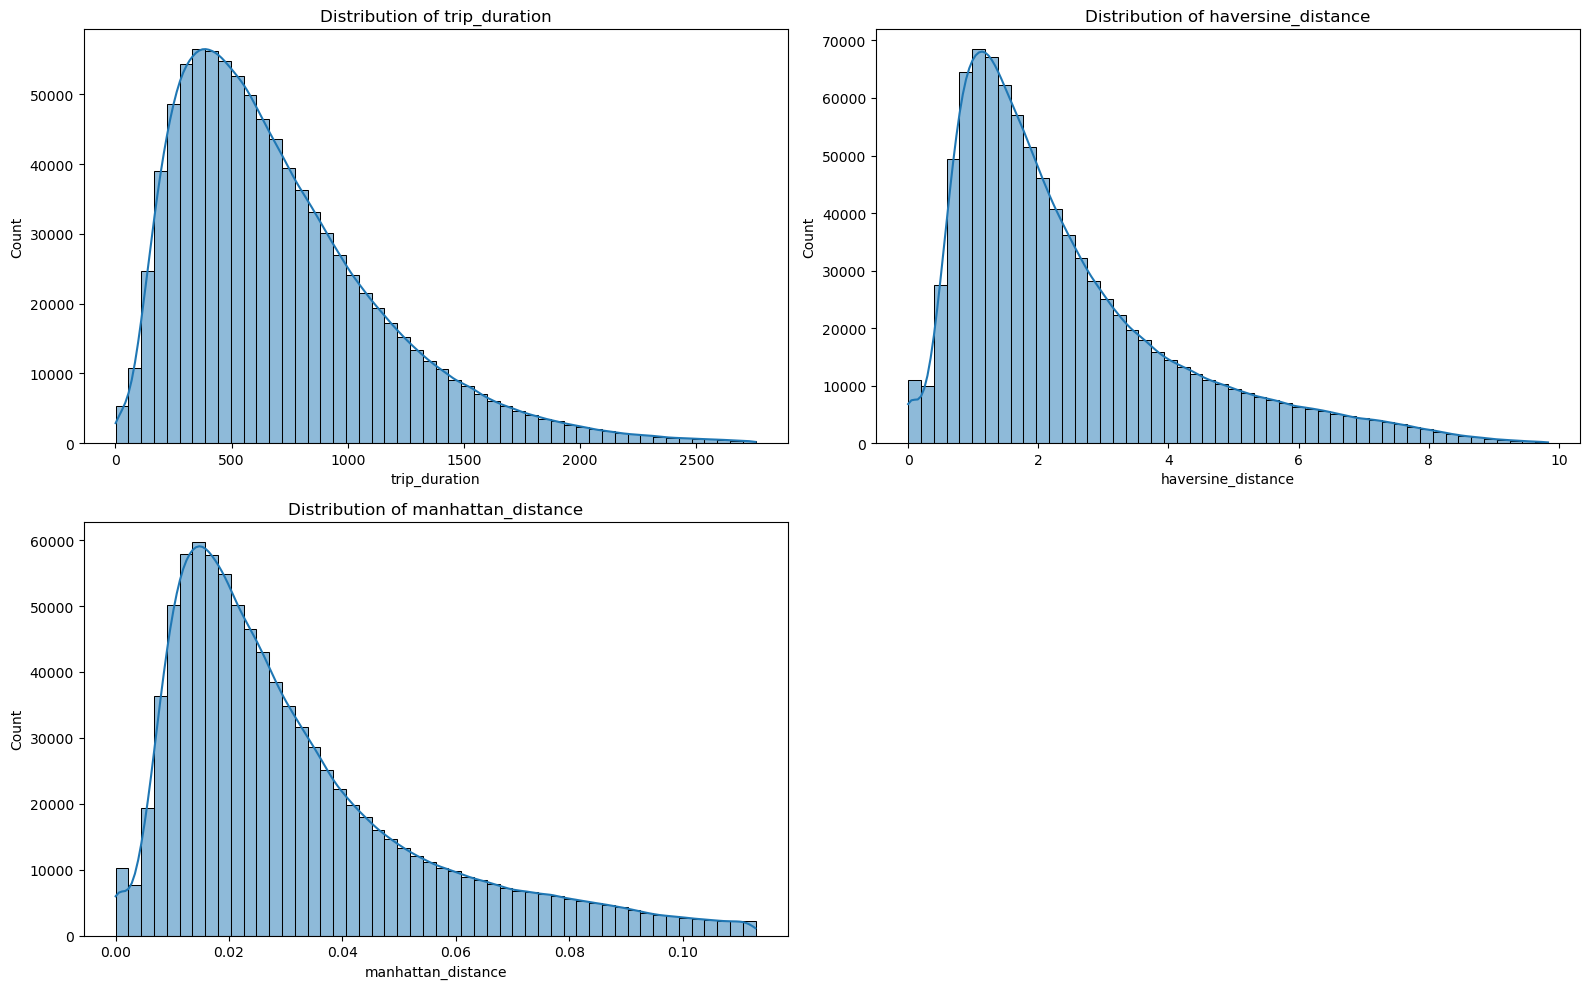

In [27]:
num_cols = ['trip_duration', 'haversine_distance', 'manhattan_distance']

plt.figure(figsize=(16,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_processed[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

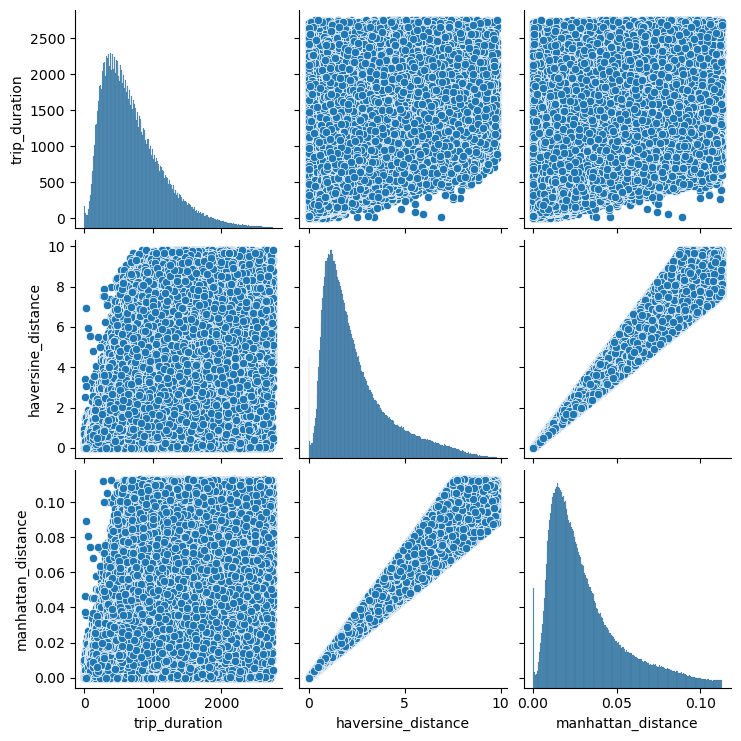

In [28]:
sns.pairplot(df_processed[['trip_duration', 'haversine_distance', 'manhattan_distance']])
plt.show()

In [29]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910076 entries, 0 to 910075
Data columns (total 60 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   pickup_longitude             910076 non-null  float64
 1   pickup_latitude              910076 non-null  float64
 2   dropoff_longitude            910076 non-null  float64
 3   dropoff_latitude             910076 non-null  float64
 4   store_and_fwd_flag           910076 non-null  object 
 5   trip_duration                910076 non-null  int64  
 6   pickup_date                  910076 non-null  object 
 7   is_holiday                   910076 non-null  int64  
 8   dayofweek                    910076 non-null  int64  
 9   month                        910076 non-null  int64  
 10  hour                         910076 non-null  int64  
 11  day                          910076 non-null  int64  
 12  rush_hours                   910076 non-null  int64  
 13 

In [30]:
df_processed['store_and_fwd_flag'] = df_processed['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

/tmp/ipykernel_48461/311394149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['log_transformed_trip_duration'] = np.log1p(df_processed['trip_duration'])


<Axes: >

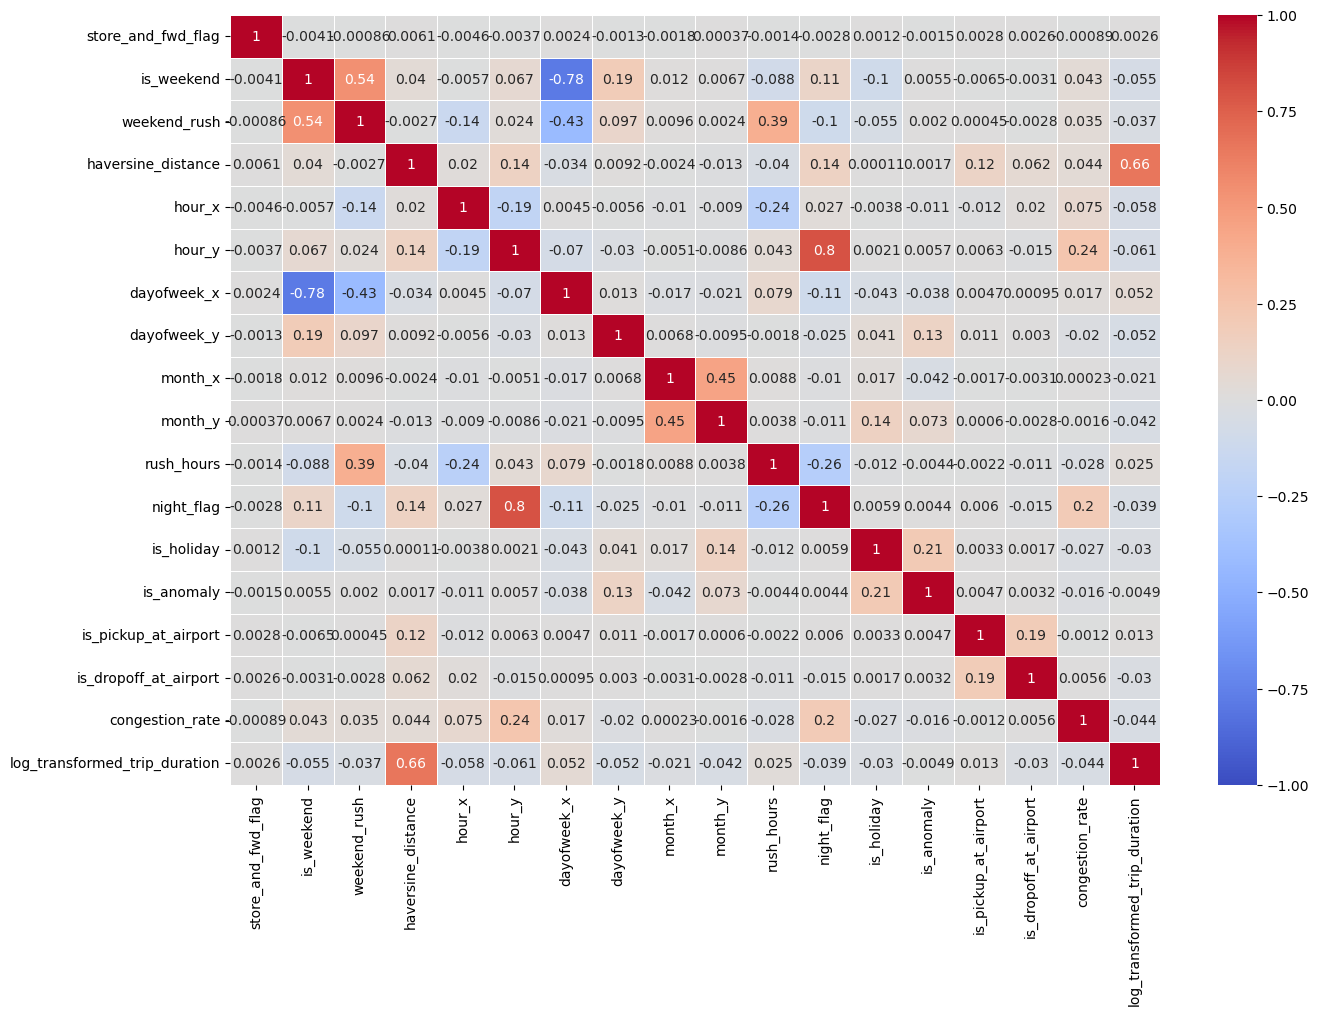

In [31]:
df_processed["weekend_rush"] = df_processed["is_weekend"] * df_processed["rush_hours"]
df_corr = df_processed[['store_and_fwd_flag','is_weekend','weekend_rush','haversine_distance','hour_x','hour_y','dayofweek_x','dayofweek_y','month_x','month_y','rush_hours','night_flag','is_holiday','is_anomaly','is_pickup_at_airport','is_dropoff_at_airport','congestion_rate']]
df_corr['log_transformed_trip_duration'] = np.log1p(df_processed['trip_duration'])
corr = df_corr.corr()

fig = plt.figure(figsize=(15,10))
sns.heatmap(corr,annot=True,linewidths=0.5,cmap='coolwarm',vmin=-1,vmax=1,center=0)